# Carving a balanced LLM evaluation suite with `datacarve`

LLM evaluation is expensive: every prompt in your suite costs judge-model calls,
human review time, or inference on every checkpoint. So eval suites are *small
by necessity* — and the question becomes: **which K prompts do you spend the
budget on?**

Pick them randomly and your suite inherits the skew of the source dataset:
whichever task type was over-collected dominates the headline score, and rare
task types are represented by a handful of prompts whose scores are noise.

[`datacarve`](https://github.com/bbonik/datacarve) selects the optimal subset
whose attributes jointly match target distributions. This notebook carves a
**500-prompt eval suite** out of
[databricks-dolly-15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k)
(15K human-written instructions, CC-BY-SA 3.0), balanced across three
dimensions *simultaneously*:

1. **task category** — the dataset's human label (categorical),
2. **topic cluster** — derived from the text itself with TF-IDF + k-means
   (categorical), showing that attributes don't need to be raw columns,
3. **prompt length** — log-scaled word count (continuous).

No API keys, no GPU: the LLM angle is the data, not inference. Runs in seconds.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datacarve import undersample_dataset

plt.style.use("ggplot")

## 1. Load the instruction dataset and look at its skew


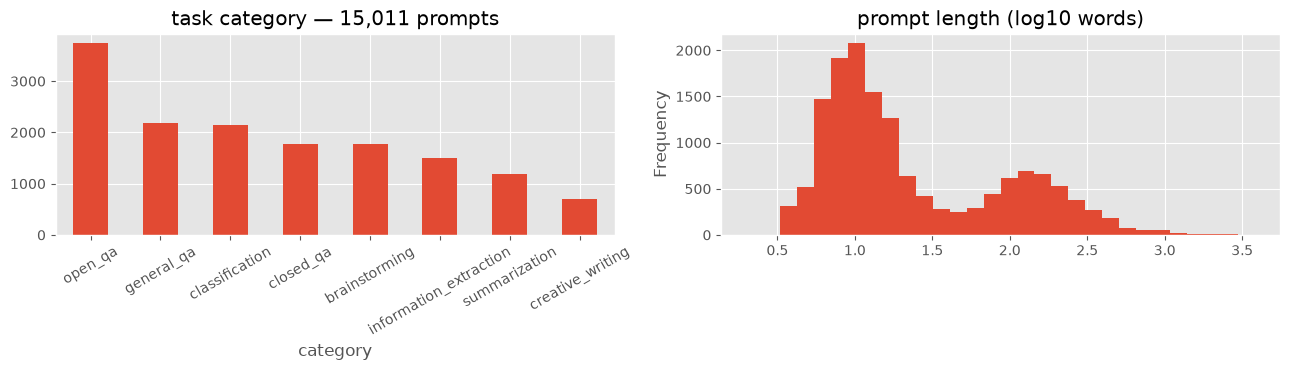

category
open_qa                   3742
general_qa                2191
classification            2136
closed_qa                 1773
brainstorming             1766
information_extraction    1506
summarization             1188
creative_writing           709
Name: count, dtype: int64

In [2]:
URL = ("https://huggingface.co/datasets/databricks/databricks-dolly-15k/"
       "resolve/main/databricks-dolly-15k.jsonl")
df = pd.read_json(URL, lines=True)

# prompt length in words (instruction + optional context), log-scaled:
# lengths are heavy-tailed (median 12 words, max ~3800), and equal-width
# bins on a heavy-tailed attribute would squash everything into one bin
prompt_words = (
    df["instruction"].str.split().str.len()
    + df["context"].fillna("").str.split().str.len()
)
df["log_prompt_words"] = np.log10(prompt_words + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
df["category"].value_counts().plot.bar(ax=axes[0], rot=30)
axes[0].set_title(f"task category — {len(df):,} prompts")
df["log_prompt_words"].plot.hist(bins=30, ax=axes[1])
axes[1].set_title("prompt length (log10 words)")
plt.tight_layout()
plt.show()

df["category"].value_counts()

Typical instruction-dataset skew: the biggest category (`open_qa`) has **5×**
more prompts than the smallest (`creative_writing`), and prompt lengths are
heavy-tailed. A random 500-prompt suite would mirror all of this.

## 2. Derive a topic dimension from the text itself

The category label is coarse — `open_qa` contains everything from sports
trivia to physics. To balance over *content*, we derive topic clusters
directly from the prompts: TF-IDF, dimensionality reduction, k-means. Plain
scikit-learn, no model downloads. (With an embedding model you'd do exactly
the same on the embeddings.)


In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import Normalizer

tfidf = TfidfVectorizer(max_features=20_000, stop_words="english",
                        sublinear_tf=True, min_df=3)
X = tfidf.fit_transform(df["instruction"])
X_red = Normalizer().fit_transform(
    TruncatedSVD(n_components=100, random_state=0).fit_transform(X)
)
df["topic"] = KMeans(n_clusters=8, random_state=0, n_init=10).fit_predict(X_red)

# label each cluster by its top TF-IDF terms, for readability
terms = np.array(tfidf.get_feature_names_out())
topic_names = {}
for c in range(8):
    in_cluster = (df["topic"] == c).to_numpy()
    centroid = np.asarray(X[in_cluster].mean(axis=0)).ravel()
    topic_names[c] = " / ".join(terms[np.argsort(centroid)[::-1][:3]])

print("cluster sizes and top terms:")
for c, size in df["topic"].value_counts().sort_index().items():
    print(f"  topic {c} ({size:>5} prompts): {topic_names[c]}")

cluster sizes and top terms:
  topic 0 (  807 prompts): given / text / reference
  topic 1 ( 1362 prompts): list / extract / passage
  topic 2 (  897 prompts): following / classify / based
  topic 3 ( 9717 prompts): difference / species / people
  topic 4 (  542 prompts): best / way / time
  topic 5 (  495 prompts): tell / following / cities
  topic 6 (  711 prompts): does / instrument / string
  topic 7 (  480 prompts): did / win / die


Also heavily skewed: one broad catch-all topic dominates, while focused topics
(classification tasks, extraction tasks, sports/history facts) are small.

## 3. Carve the balanced suite

Three dimensions, one call. `'uniform'` means *equal counts per value* for the
two categorical dimensions and a *flat histogram* for the (log) length.


In [4]:
data = np.column_stack([
    df["category"].astype("category").cat.codes.to_numpy(float),
    df["topic"].to_numpy(float),
    df["log_prompt_words"].to_numpy(float),
])

mask = undersample_dataset(
    data=data,
    data_to_keep=500,
    target_distribution="uniform",
    categorical_dims=[0, 1],   # category and topic; length stays numeric
    bins=10,
    verbose=False,
    scatterplot_matrix=False,
)

suite = df[mask]
print(f"carved {mask.sum()} prompts out of {len(df):,}")

carved 500 prompts out of 15,011


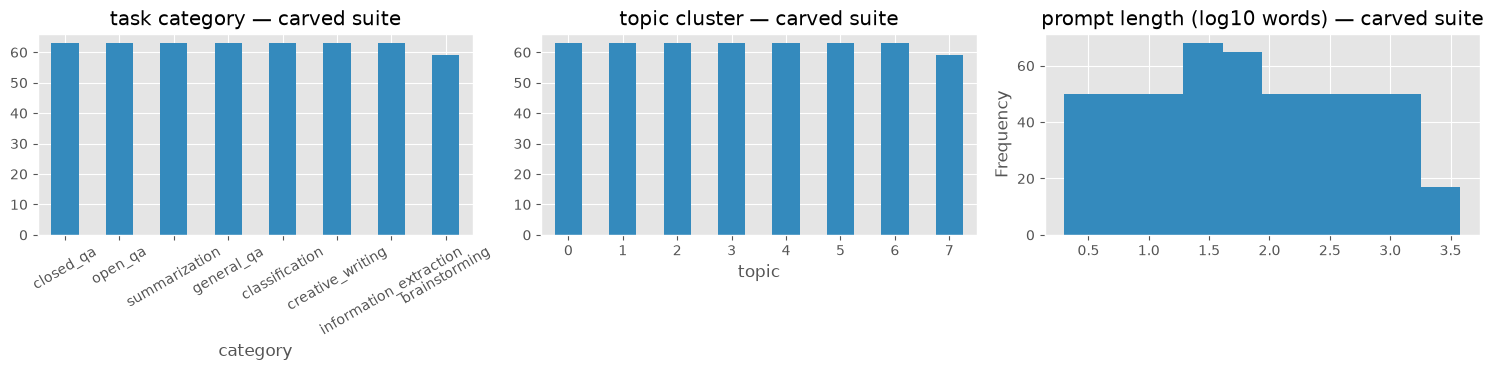

category counts: {'closed_qa': 63, 'open_qa': 63, 'summarization': 63, 'general_qa': 63, 'classification': 63, 'creative_writing': 63, 'information_extraction': 63, 'brainstorming': 59}
topic counts:    {0: 63, 1: 63, 2: 63, 3: 63, 4: 63, 5: 63, 6: 63, 7: 59}


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
suite["category"].value_counts().plot.bar(ax=axes[0], rot=30, color="#348ABD")
axes[0].set_title("task category — carved suite")
suite["topic"].value_counts().sort_index().plot.bar(
    ax=axes[1], rot=0, color="#348ABD")
axes[1].set_title("topic cluster — carved suite")
suite["log_prompt_words"].plot.hist(bins=10, ax=axes[2], color="#348ABD")
axes[2].set_title("prompt length (log10 words) — carved suite")
plt.tight_layout()
plt.show()

print("category counts:", suite["category"].value_counts().to_dict())
print("topic counts:   ", suite["topic"].value_counts().sort_index().to_dict())

Every task category at ~63 prompts, every topic cluster at ~63 prompts, and a
near-flat length profile — **all three at once**, selected from real prompts
only. The 5× category imbalance and the dominant catch-all topic are gone.

A model's score on this suite is no longer an artifact of what dolly-15k
happened to over-collect: each task type and each topic contributes equal
evidence, and long prompts are tested as thoroughly as short ones.

## Wrap-up

- **Attributes don't need to be raw columns.** One dimension here was derived
  from the text itself (TF-IDF + k-means). Embedding clusters, difficulty
  scores, safety categories, or language IDs slot in the same way.
- **Transform heavy-tailed attributes first.** We carved over log-length;
  equal-width bins on raw lengths would have been dominated by outliers.
- The same recipe covers **SFT mixture curation** (carve a training subset to
  an exact category mixture using custom per-dimension targets, e.g.
  ``target_distribution=[[3, 3, 2, 2, ...], "uniform", "uniform"]``),
  **red-teaming pools**, and **human-eval batches**.

**Install:** `pip install datacarve` &nbsp;|&nbsp; **Repo:**
<https://github.com/bbonik/datacarve>

Dataset: [databricks-dolly-15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k)
(CC-BY-SA 3.0).
